#### Chain Of Thoughts With RAG
What is Chain-of-Thought (CoT) in RAG?

CoT reasoning breaks down a complex question into intermediate steps, and allows retrieval + reflection at each step before answering.

User Query
   ↓
- Step 1: Decompose question → sub-steps (Reason)
- Step 2: Retrieve docs per step (Act)
- Step 3: Combine context (Observe)
- Step 4: Final answer generation (Reflect)

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_classic.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [3]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
docs = TextLoader("research_notes.txt", encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size= 500, chunk_overlap= 50)
chunks = splitter.split_documents(docs)
embedding = OllamaEmbeddings(model= "qwen3-embedding:8b")
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [4]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model= "gemma4:e4b")

In [5]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [7]:
# -------------------------------
# 3. Nodes
# -------------------------------
# a. Plan sub-questions
def plan_steps(state: RAGCoTState)-> RAGCoTState:
    prompt = f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result = llm.invoke(prompt).content
    subqs = [line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_steps": subqs})


In [8]:
# b. Retrieve for each step
def retrieve_per_step(state: RAGCoTState)-> RAGCoTState:
    all_docs=[]
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs": all_docs})


In [9]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

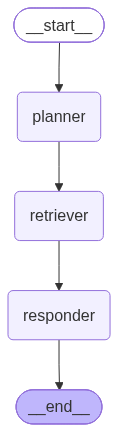

In [10]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------
builder = StateGraph(RAGCoTState)
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [11]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are the additional eperiments in Transformer eveluation?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ['This question requires a shift from simply listing metrics to analyzing the *limitations* of existing metrics and the *directions* of current AI research.', 'Here is the breakdown into 3 reasoning steps:', '### Step 1: Establishing the Baseline (Critiquing the Status Quo)', '*   **Goal:** Identify the limitations of traditional, surface-level evaluation methods.', '*   **Reasoning Focus:** Standard metrics (BLEU, ROUGE, Perplexity) measure *n-gram overlap* or *likelihood* but fail to capture semantic meaning, common sense, or complex reasoning.', '*   **Expected Output:** Understanding that the evaluation must move beyond simple word matching to judge *quality* and *utility*.', '### Step 2: Determining the Areas of Failure (Identifying Novel Capabilities)', '*   **Goal:** Determine *what* capabilities the Transformers lack or need to prove, beyond basic language modeling.', '*   **Reasoning Focus:** Current research has highlighted failures in specific, high-level